In [2]:
import os
import cv2
import glob
import torch
import numpy as np
from PIL import Image
import torch.nn as nn
from tqdm import tqdm
import torch.optim as optim
import torchvision.utils as vutils
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from sklearn.preprocessing import MinMaxScaler
from torchvision.datasets import ImageFolder
from torchvision import datasets

In [3]:
# Define paths
mnist_train = datasets.MNIST(root='./data', train=True, download=True)
mnist_test = datasets.MNIST(root='./data', train=False, download=True)

# Create directories for the ImageFolder structure
os.makedirs('./mnist/train', exist_ok=True)
os.makedirs('./mnist/test', exist_ok=True)

# Function to save images in ImageFolder format
def save_mnist_images(mnist_dataset, save_dir):
    for idx, (image, label) in enumerate(mnist_dataset):
        label_dir = os.path.join(save_dir, str(label))
        os.makedirs(label_dir, exist_ok=True)
        image_path = os.path.join(label_dir, f"{idx}.png")
        image.save(image_path)

# Save the train and test images
save_mnist_images(mnist_train, './mnist/train')
save_mnist_images(mnist_test, './mnist/test')

# Now you can use ImageFolder to load the dataset
train_data_dir = './mnist/train'
test_data_dir = './mnist/test'


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 15.9MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.39MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.01MB/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [4]:
# Set device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [5]:
# Define data transformations with MNIST mean and standard deviation
mnist_mean = 0.1307
mnist_std = 0.3081
batch_size= 256
# Define data transformations for training and testing
train_transform = transforms.Compose([
    #transforms.RandomRotation(degrees=(-20, 20)),
    #transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    #transforms.RandomGrayscale(p=0.1),
    #transforms.RandomAffine(degrees=(-10, 10), translate=(0.1, 0.1), scale=(0.9, 1.1), shear=(-10, 10)),
    #transforms.RandomPerspective(distortion_scale=0.5, p=0.5),
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize((mnist_mean,), (mnist_std,))
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(28),
    transforms.ToTensor(),
    transforms.Normalize((mnist_mean,), (mnist_std,))
])

# Load the MNIST dataset using ImageFolder
train_dataset = ImageFolder(root=train_data_dir, transform=train_transform)
test_dataset = ImageFolder(root=test_data_dir, transform=test_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory = True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory = True)

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [6]:
print("Training Dataset:")
print(f"  Size: {len(train_dataset)}")
print(f"  Shape: {next(iter(train_loader))[0].shape}")
print(f"  Batch Size: {train_loader.batch_size}")

print("\nTesting Dataset:")
print(f"  Size: {len(test_dataset)}")
print(f"  Shape: {next(iter(test_loader))[0].shape}")
print(f"  Batch Size: {test_loader.batch_size}")

Training Dataset:
  Size: 60000
  Shape: torch.Size([256, 1, 28, 28])
  Batch Size: 256

Testing Dataset:
  Size: 10000
  Shape: torch.Size([256, 1, 28, 28])
  Batch Size: 256


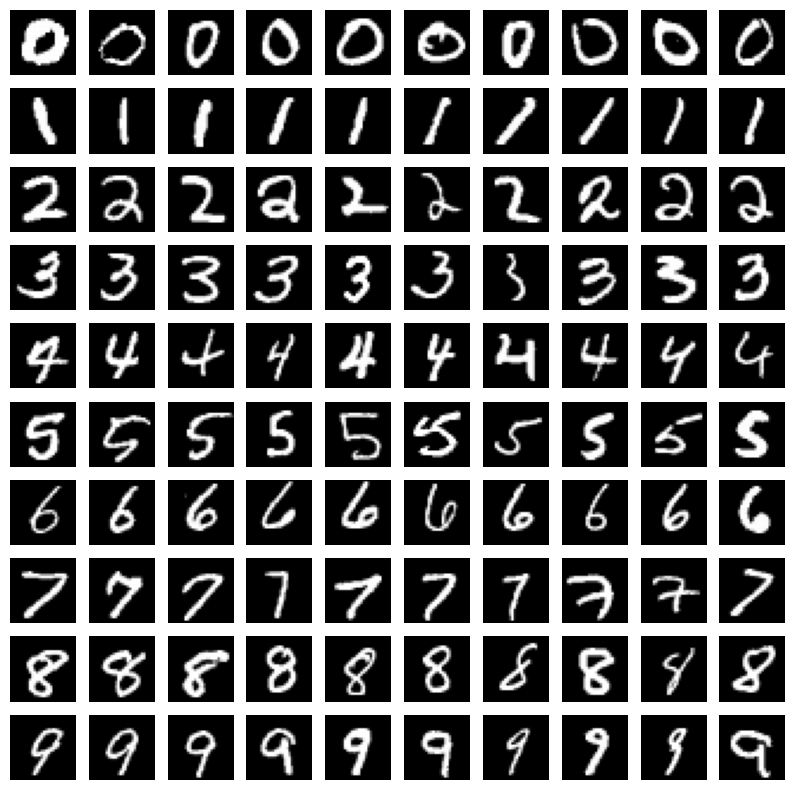

In [7]:
# Dictionary to store images for each class
class_images = {i: [] for i in range(10)}

# Traverse through the folder and collect images
for class_label in range(10):
    class_path = os.path.join(train_data_dir, str(class_label))

    # Iterate through images in the class folder
    for image_file in os.listdir(class_path)[:10]:
        image_path = os.path.join(class_path, image_file)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        class_images[class_label].append(image)

# Plot 10x10 grid
fig, axs = plt.subplots(10, 10, figsize=(10, 10))

for i in range(10):
    for j in range(10):
        axs[i, j].imshow(class_images[i][j], cmap="gray")
        axs[i, j].axis("off")

plt.show()

Classifier

In [8]:
class Classifier(nn.Module):
    def __init__(self, nc, ncf):
        super(Classifier, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ncf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ncf),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ncf, ncf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ncf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ncf * 2, ncf * 4, 3, 1, 0, bias=False),
            nn.Flatten(),
            nn.Linear(ncf * 100, ncf * 2),
            nn.ReLU(),

            nn.Linear(ncf * 2, 10)
        )

    def forward(self, input):
        return self.main(input)

In [9]:
class Generator(nn.Module):
    def __init__(self, nz, ngf, nc=1, n_classes=10):  # Default nc=1 for grayscale output, n_classes=10
        super(Generator, self).__init__()
        self.nz = nz
        self.n_classes = n_classes

        # Define the embedding layer for class matrix diagonal
        self.embedding = nn.Linear(n_classes, nz)

        # Adjust layers before concatenation to take nz*2 channels
        self.layers_before_concat = nn.Sequential(
            nn.ConvTranspose2d(nz * 2, ngf, 4, 1, 0),  # Adjusted input channels to nz*2
            nn.BatchNorm2d(ngf),
            #nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, ngf * 2, 4, 1, 0),
            nn.BatchNorm2d(ngf * 2),
            #nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf * 4, 4, 1, 0),
            nn.BatchNorm2d(ngf * 4),
            #nn.Dropout2d(0.1),
            nn.ReLU(True),
        )

        # Layers after concatenation remain the same
        self.layers_after_concat = nn.Sequential(
            nn.ConvTranspose2d(ngf * 4 + 1, ngf * 8, 4, 1, 1),
            nn.BatchNorm2d(ngf * 8),
            nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 1, 1),
            nn.BatchNorm2d(ngf * 4),
            nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1),
            nn.BatchNorm2d(ngf * 2),
            nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 1, 0),
            nn.BatchNorm2d(ngf),
            nn.Dropout2d(0.1),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 1, 1),
            nn.Tanh(),
        )

    def forward(self, latent_vector, conditioning_vector):
        # Get the argmax of the conditioning vector
        argmax_index = torch.argmax(conditioning_vector, dim=1)

        # Create a class matrix based on the argmax index
        class_matrix = torch.zeros((latent_vector.size(0), self.n_classes, self.n_classes)).to(latent_vector.device)
        for i, idx in enumerate(argmax_index):
            class_matrix[i, idx, :] = 1
            class_matrix[i, :, idx] = 1

        # Map the conditioning vector to nz dimensions
        embedding_vector = self.embedding(conditioning_vector).unsqueeze(2).unsqueeze(3)

        # Concatenate the latent vector with the conditioned input
        concat1 = torch.cat([latent_vector, embedding_vector], dim=1)

        # Pass the combined input through the layers before concatenation
        upsample1 = self.layers_before_concat(concat1)

        # Ensure class_matrix has the correct shape for concatenation
        class_matrix = class_matrix.unsqueeze(1)

        # Concatenate the upsampled noise with the class matrix
        concat2 = torch.cat([upsample1, class_matrix], dim=1)

        # Pass through the layers after concatenation to generate the output
        upsample2 = self.layers_after_concat(concat2)

        return upsample2


In [10]:
# Example usage:
nz = 100
ngf = 64
nc = 1
n_classes = 10
ncf = 64

# Instantiate the generator and classifier
gen = Generator(nz, ngf, nc, n_classes)
csf = Classifier(nc, ncf)

# Random latent vector
latent_vector = torch.randn((5, nz,1,1))

# Define the conditioning random vector
n_dim_random_vector = torch.randn((5, n_classes))
print("Random vector:", n_dim_random_vector)

# Apply softmax to the random vector
conditioning_vector = F.softmax(n_dim_random_vector, dim=1)
print("Softmaxed vector:", conditioning_vector)

# Generate image
generated_image = gen(latent_vector, conditioning_vector)
print("Generated image shape:", generated_image.shape)

# Pass the generated image through the classifier
classifier_output = csf(generated_image)
print("Classifier output shape:", classifier_output.shape)

Random vector: tensor([[ 0.2049,  0.9941,  0.0108, -0.6648, -1.0658, -1.4615, -0.3997, -0.7071,
         -1.9579,  0.7213],
        [-0.4753, -0.8700,  0.7983, -0.0520,  0.1521,  0.9412, -2.0172, -0.9808,
         -1.5211, -0.3711],
        [-0.8720, -2.1352, -0.2120,  1.4902, -1.4402,  0.3059, -2.2061, -0.0706,
          0.3301,  0.6209],
        [-1.6885, -2.1522,  1.7209, -1.1751,  0.2760, -0.4647, -0.4168,  0.1756,
          0.2875, -0.5570],
        [ 0.0358, -1.0551, -0.0638,  1.3018, -0.6088, -0.3388, -0.4735, -2.1254,
          1.7033, -0.2209]])
Softmaxed vector: tensor([[0.1307, 0.2877, 0.1076, 0.0548, 0.0367, 0.0247, 0.0714, 0.0525, 0.0150,
         0.2190],
        [0.0665, 0.0448, 0.2375, 0.1015, 0.1245, 0.2740, 0.0142, 0.0401, 0.0234,
         0.0737],
        [0.0358, 0.0101, 0.0693, 0.3802, 0.0203, 0.1163, 0.0094, 0.0798, 0.1192,
         0.1594],
        [0.0155, 0.0098, 0.4696, 0.0259, 0.1107, 0.0528, 0.0554, 0.1001, 0.1120,
         0.0481],
        [0.0725, 0.0244, 

In [11]:
def train(model, train_loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc="Training")

    for i, (inputs, labels) in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({"Batch Loss": loss.item()})

    average_loss = running_loss / len(train_loader)
    accuracy = correct / total

    return average_loss, accuracy

In [12]:
def test(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        pbar = tqdm(enumerate(test_loader), total=len(test_loader), desc="Testing")

        for i, (inputs, labels) in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            pbar.set_postfix({"Batch Loss": loss.item()})

    average_loss = running_loss / len(test_loader)
    accuracy = correct / total

    return average_loss, accuracy

In [ ]:
# # Classifier Hyperparameters
# ncf = 64  # Number of classifier filters
# nc = 1    # Number of channels in the input images (1 for grayscale)

# # Initialize your model, optimizer, and criterion
# csf = Classifier(nc, ncf).to(device)

# csf_optimizer = optim.Adam(csf.parameters(), lr=0.01)
# criterion = nn.CrossEntropyLoss()

# # Lists to store the training and testing loss and accuracy values
# train_losses = []
# train_accuracies = []
# test_losses = []
# test_accuracies = []

# # Variable to store the best test accuracy
# best_test_accuracy = 0.0
# best_model_state = None

# # Training loop for 10 epochs
# num_epochs = 25
# for epoch in range(num_epochs):
#     # Training
#     train_loss, train_accuracy = train(csf, train_loader, csf_optimizer, criterion, device)
#     train_losses.append(train_loss)
#     train_accuracies.append(train_accuracy)

#     # Testing
#     test_loss, test_accuracy = test(csf, test_loader, device)
#     test_losses.append(test_loss)
#     test_accuracies.append(test_accuracy)

#     # Check if this is the best model so far
#     if test_accuracy > best_test_accuracy:
#         best_test_accuracy = test_accuracy
#         best_model_state = csf.state_dict()

#     print(f"\nEpoch {epoch + 1}/{num_epochs}")
#     print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")
#     print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


Testing: 100%|██████████| 40/40 [00:03<00:00, 11.48it/s, Batch Loss=0.155]


Epoch 1/25
Train Loss: 2.2028, Train Accuracy: 0.8498
Test Loss: 0.1849, Test Accuracy: 0.9451



Testing: 100%|██████████| 40/40 [00:03<00:00, 12.37it/s, Batch Loss=0.0312]


Epoch 2/25
Train Loss: 0.1480, Train Accuracy: 0.9570
Test Loss: 0.1078, Test Accuracy: 0.9663



Testing: 100%|██████████| 40/40 [00:05<00:00,  7.20it/s, Batch Loss=0.0111]

...


Testing: 100%|██████████| 40/40 [00:03<00:00, 11.77it/s, Batch Loss=0.000387]



Epoch 24/25
Train Loss: 0.0558, Train Accuracy: 0.9865
Test Loss: 0.0678, Test Accuracy: 0.9848


Testing: 100%|██████████| 40/40 [00:03<00:00, 12.06it/s, Batch Loss=0.0135]



Epoch 25/25
Train Loss: 0.0734, Train Accuracy: 0.9832
Test Loss: 0.0817, Test Accuracy: 0.9804


RuntimeError: Parent directory MNIST-Inversion does not exist.

In [ ]:
# # Save the best model
# if best_model_state is not None:
#     torch.save(best_model_state, '/content/drive/MyDrive/MNIST-Inversion/mnist_csf_10_noaug.pth')
#     print(f"Best model saved with test accuracy: {best_test_accuracy:.4f}")
# else:
#     print("No model was saved.")

NameError: name 'best_model_state' is not defined

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


SAE TRAIL ON WHOLE TRAIN SET

---



In [14]:
ncf = 64
nc = 1

# csf = Classifier(nc, ncf).to(device)
# csf.load_state_dict(torch.load('MNIST-Inversion/mnist_csf_10.pth'))
criterion=nn.CrossEntropyLoss()
classifier = Classifier(nc, ncf).to(device)
classifier.load_state_dict(torch.load('/content/drive/MyDrive/mnist_csf_10 (1).pth', map_location=torch.device('cpu')))
# test_loss, test_acc = test(classifier,test_loader,device)
# print("\nTest Accuracy: ",test_acc)

<ipython-input-14-ae11b25f6cf6>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  classifier.load_state_dict(torch.load('/content/drive/MyDrive/mnist_csf_10 (1).pth', map_loc

<All keys matched successfully>

Implementation of Sparse autoencoder


*   Pass the train set again through the pretrained classifier and use a hook to get the features from the 9th layer for each image
*   Use this feature as the input to SAE and the output will be a reconstruction version of the important part of the input features

*   Pass this outpt feature to the classifier
*   List item





In [27]:
print(classifier)

Classifier(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2, inplace=True)
    (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (7): Flatten(start_dim=1, end_dim=-1)
    (8): Linear(in_features=6400, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [177]:
train_loader

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# from utils import mnist, plot_graphs, plot_mnist # functions for loading and plotting MNIST
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

# Step 1: Hook for feature extraction
def hook_fn(module, input, output):

    features.append(output.detach())

# Step 2: Load the MNIST dataset
transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize((0.5,), (0.5,))
])

# Step 4: Register the hook at the 9th layer (first Linear layer after convolution layers)
features = []  # List to store extracted features

# Register hook on the 6th layer (the first Linear layer)
hook = classifier.main[8].register_forward_hook(hook_fn)

# Step 5: Pass the data through the classifier and extract features
classifier.eval()  # Set the classifier to evaluation mode

# Iterate over the dataset to extract features
with torch.no_grad():
    for images, labels in train_loader:
        outputs = classifier(images)  # Forward pass through the classifier
    hook.remove()

# At this point, the `features` list will have the extracted features from the 9th layer
# `features[0]` will contain the features from the first batch
extracted_features = torch.cat(features, dim=0)

# Step 6: Check shape of extracted features (expected: [batch_size, 128, 5, 5])
print("Extracted features shape:", extracted_features.shape)

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [229]:
features

[tensor([[ -51.1035,  -54.4685,  -46.2571,  ...,  -81.8709,  -32.6805,
           -40.9432],
         [ -27.5593,  -39.6748,  -38.2441,  ...,  -54.9814,  -40.8524,
           -32.6289],
         [ -30.9240,  -35.4024,  -26.2831,  ...,  -41.8406,  -18.7891,
           -27.8464],
         ...,
         [ -61.9568,  -73.0017,  -52.0005,  ..., -106.6970,  -41.6720,
           -45.0260],
         [ -46.5115,  -47.9830,  -41.9426,  ...,  -78.1811,  -33.4279,
           -33.5839],
         [ -34.1738,  -37.7400,  -24.5406,  ...,  -57.5893,  -28.9525,
           -33.8428]]),
 tensor([[ -64.5334,  -82.7846,  -48.7902,  ...,  -91.4485,  -40.8270,
           -35.2749],
         [ -48.4730,  -75.0720,  -34.2084,  ..., -108.1171,  -35.2576,
           -50.6704],
         [ -44.5174,  -42.6657,  -40.8959,  ...,  -61.7089,  -28.7826,
           -37.6421],
         ...,
         [ -50.1831,  -65.9015,  -53.6962,  ...,  -92.7722,  -40.5376,
           -37.4665],
         [ -47.5356,  -65.1239,  -33.713

In [230]:
extracted_features

tensor([[-51.1035, -54.4685, -46.2571,  ..., -81.8709, -32.6805, -40.9432],
        [-27.5593, -39.6748, -38.2441,  ..., -54.9814, -40.8524, -32.6289],
        [-30.9240, -35.4024, -26.2831,  ..., -41.8406, -18.7891, -27.8464],
        ...,
        [-46.3800, -56.8931, -41.1771,  ..., -86.0040, -21.8138, -26.4258],
        [-25.3238, -39.8136, -32.6840,  ..., -72.2196, -29.5926, -48.0078],
        [-39.0471, -49.6020, -39.0128,  ..., -69.9960, -14.6754, -22.2918]])

In [231]:
print(extracted_features.shape)

torch.Size([60000, 128])


In [271]:
print(f"Mean: {extracted_features.mean().item()}")
print(f"Std: {extracted_features.std().item()}")
print(f"Min: {extracted_features.min().item()}")
print(f"Max: {extracted_features.max().item()}")

Mean: -36.013580322265625
Std: 19.458263397216797
Min: -129.5471649169922
Max: 33.33001708984375


Implementation of SAE along using KL loss TRAIL1

Architecture_2 SAE with L1 loss

SAE with KL Divergence TRAIL2

In [264]:
import torch
import torch.nn as nn
import torch.optim as optim

class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, sparsity_level=0.05, beta=1e-3):
        super(SparseAutoencoder, self).__init__()
        # Hyperparameters for sparsity
        self.sparsity_level = sparsity_level
        self.beta = beta

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        hidden = self.encoder(x)
        reconstructed = self.decoder(hidden)
        return hidden, reconstructed

    def sparsity_loss(self, hidden_activations):
        # Calculate average activation of hidden layer neurons
        rho_hat = torch.mean(hidden_activations, dim=0)
        rho = self.sparsity_level

        # KL Divergence sparsity penalty
        sparsity_penalty = torch.sum(
            rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))
        )
        return sparsity_penalty

# Parameters
input_dim = 128
hidden_dim = 512
sparsity_level = 0.05  # Desired sparsity level
beta = 1e-7  # Weight of sparsity penalty
epochs = 20
batch_size = 256
learning_rate = 2*1e-2

# Min-max normalization to [0, 1]
min_val = extracted_features.min()
max_val = extracted_features.max()
normalized_features = (extracted_features - min_val) / (max_val - min_val + 1e-8)  # Avoid division by zero

# Instantiate model
sae = SparseAutoencoder(input_dim, hidden_dim, sparsity_level, beta)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(sae.parameters(), lr=learning_rate)

# Training loop
print("Training the Sparse Autoencoder...")
dataset = torch.utils.data.TensorDataset(normalized_features)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

for epoch in range(epochs):
    epoch_loss = 0
    for batch in dataloader:
        batch_data = batch[0]
        optimizer.zero_grad()

        # Forward pass
        hidden, reconstructed = sae(batch_data)

        # Reconstruction loss
        mse_loss = criterion(reconstructed, batch_data)

        # Sparsity loss
        sparsity_loss = sae.sparsity_loss(hidden)

        # Total loss
        loss = mse_loss + beta * sparsity_loss
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss / len(dataloader):.4f}")

print("Training completed!")

# sae.eval()
# Attach hook to capture activations from the hidden layer
hidden_activations = []

def hook_fn(module, input, output):
    hidden_activations.append(output)

hook = sae.encoder[1].register_forward_hook(hook_fn)

# Forward pass with trained Sparse Autoencoder
print("Forward passing through the SAE to capture activations...")
with torch.no_grad():
    sae(normalized_features) #whole 60000 is passed in one batch so basically the hidden_activation consists of 128 activation tensor values for 60000 points

# Detach the hook
hook.remove()

Training the Sparse Autoencoder...
Epoch [1/20], Loss: 0.0059
Epoch [2/20], Loss: 0.0021
Epoch [3/20], Loss: 0.0020
Epoch [4/20], Loss: 0.0015
Epoch [5/20], Loss: 0.0012
Epoch [6/20], Loss: 0.0010
Epoch [7/20], Loss: 0.0009
Epoch [8/20], Loss: 0.0008
Epoch [9/20], Loss: 0.0008
Epoch [10/20], Loss: 0.0007
Epoch [11/20], Loss: 0.0006
Epoch [12/20], Loss: 0.0007
Epoch [13/20], Loss: 0.0006
Epoch [14/20], Loss: 0.0006
Epoch [15/20], Loss: 0.0006
Epoch [16/20], Loss: 0.0006
Epoch [17/20], Loss: 0.0006
Epoch [18/20], Loss: 0.0006
Epoch [19/20], Loss: 0.0006
Epoch [20/20], Loss: 0.0006
Training completed!
Forward passing through the SAE to capture activations...


In [244]:
normalized_features

tensor([[0.4816, 0.4610, 0.5114,  ..., 0.2927, 0.5947, 0.5440],
        [0.6262, 0.5518, 0.5606,  ..., 0.4578, 0.5445, 0.5950],
        [0.6055, 0.5780, 0.6340,  ..., 0.5385, 0.6800, 0.6244],
        ...,
        [0.5106, 0.4461, 0.5426,  ..., 0.2673, 0.6614, 0.6331],
        [0.6399, 0.5509, 0.5947,  ..., 0.3520, 0.6137, 0.5006],
        [0.5556, 0.4908, 0.5558,  ..., 0.3656, 0.7053, 0.6585]])

In [265]:
hidden_activations=torch.cat(hidden_activations, dim=0)
print(f"Mean: {hidden_activations.mean().item()}")
print(f"Std: {hidden_activations.std().item()}")
print(f"Min: {hidden_activations.min().item()}")
print(f"Max: {hidden_activations.max().item()}")

Mean: 0.011919353157281876
Std: 0.0666041299700737
Min: 2.1319831738441324e-24
Max: 0.9405840039253235


In [ ]:
print(hidden_activations.shape)

torch.Size([60000, 512])


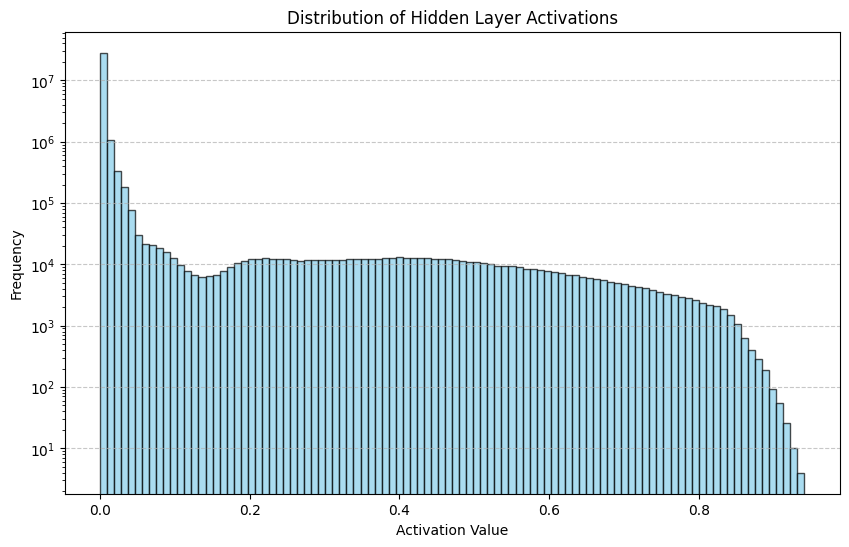

In [266]:
import matplotlib.pyplot as plt

# Assuming hidden_activations is already obtained as a tensor
hidden_activations_np = hidden_activations.detach().cpu().numpy()  # Convert to numpy array

# Flatten the tensor to analyze all activations across images and neurons
flattened_activations = hidden_activations_np.flatten()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(flattened_activations, bins=100, color='skyblue', alpha=0.7, edgecolor='black')
plt.title("Distribution of Hidden Layer Activations")
plt.yscale('log')
plt.xlabel("Activation Value")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


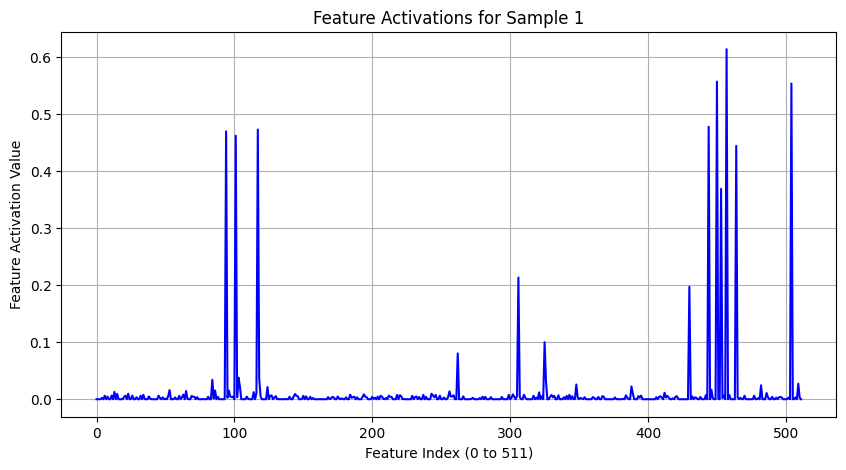

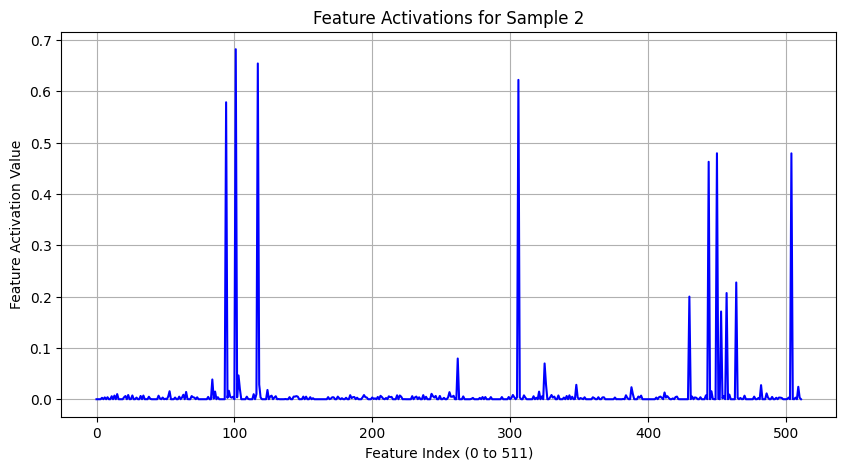

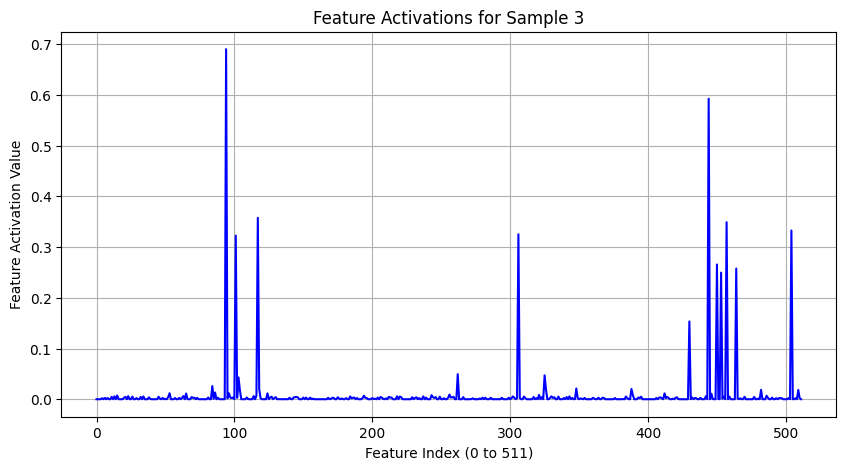

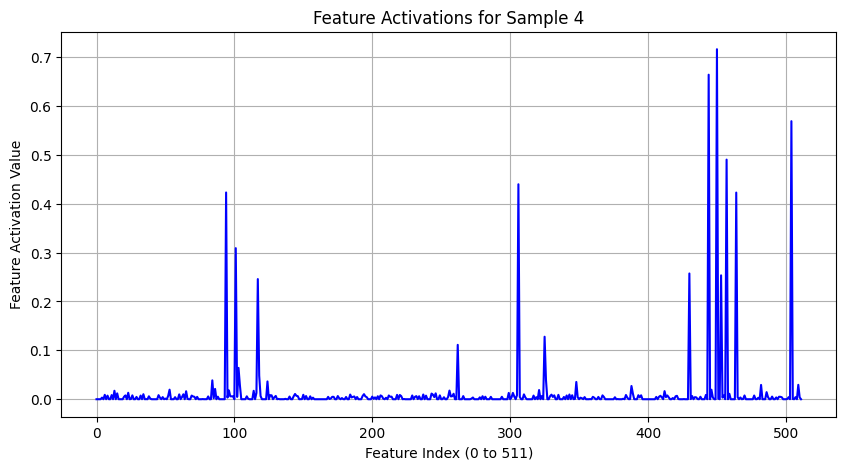

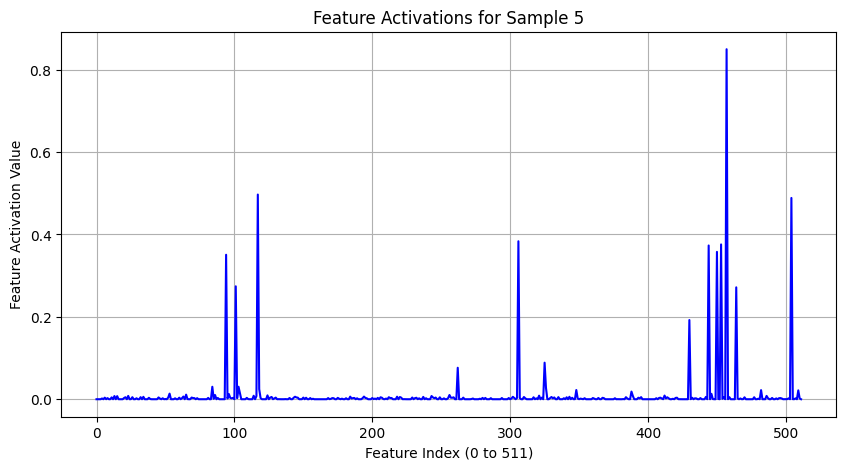

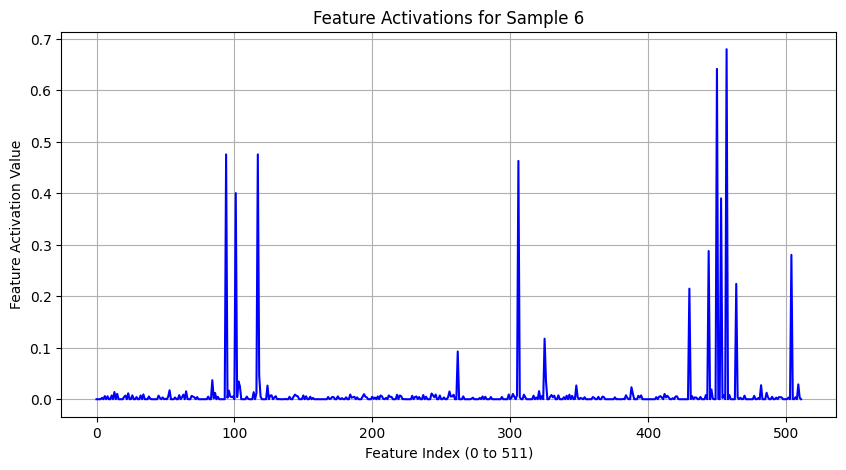

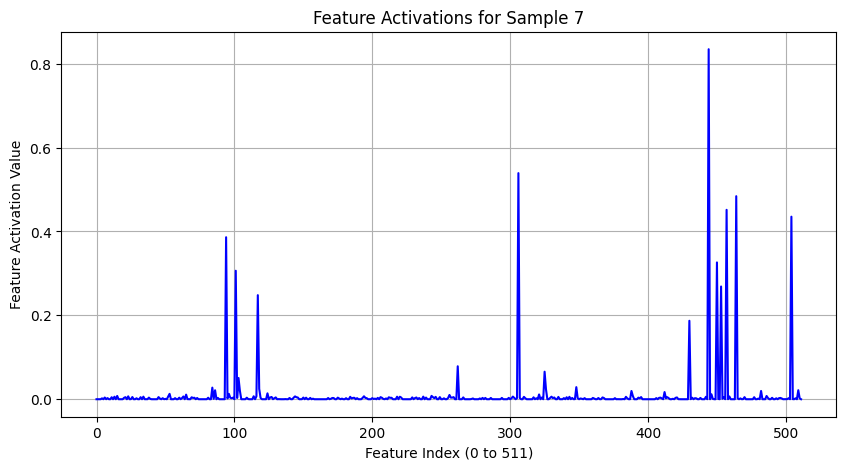

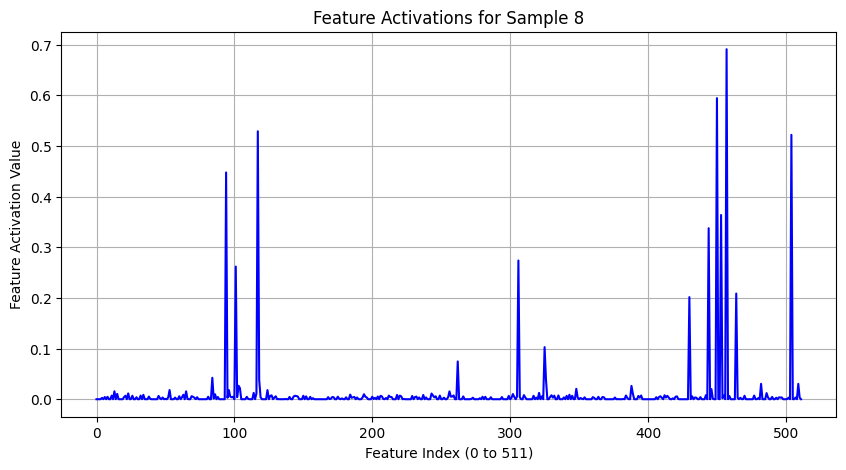

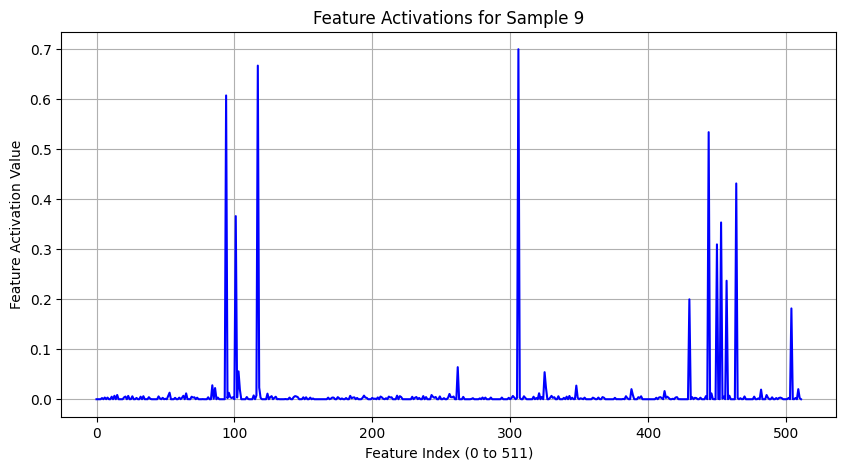

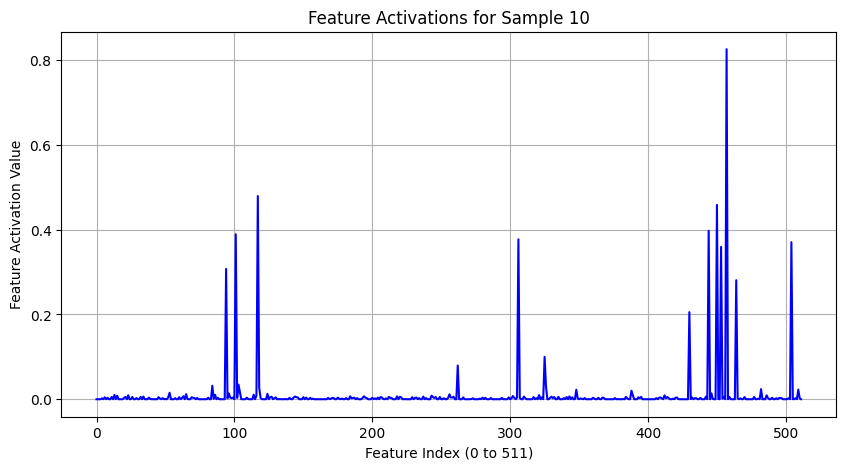

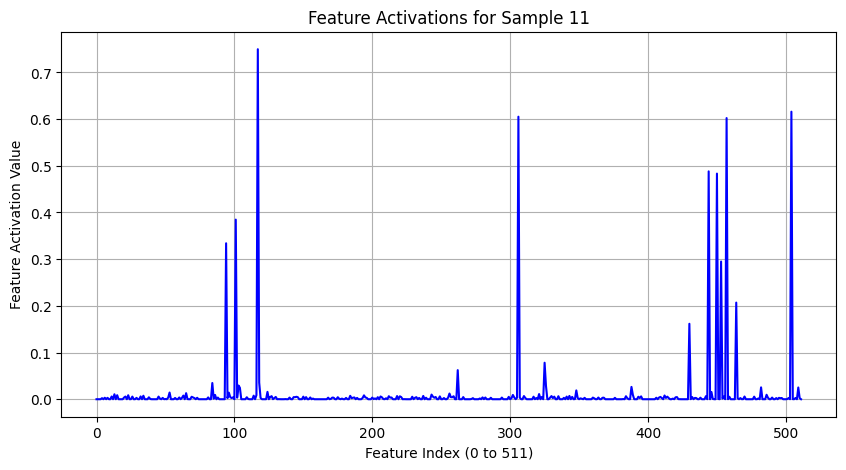

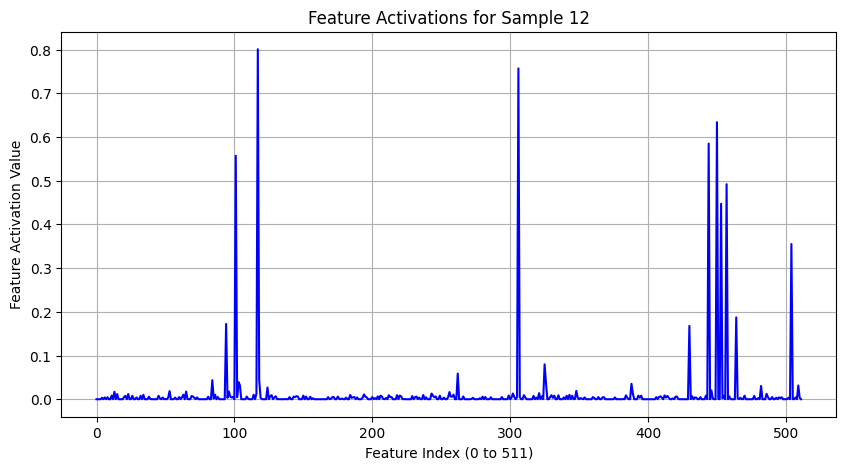

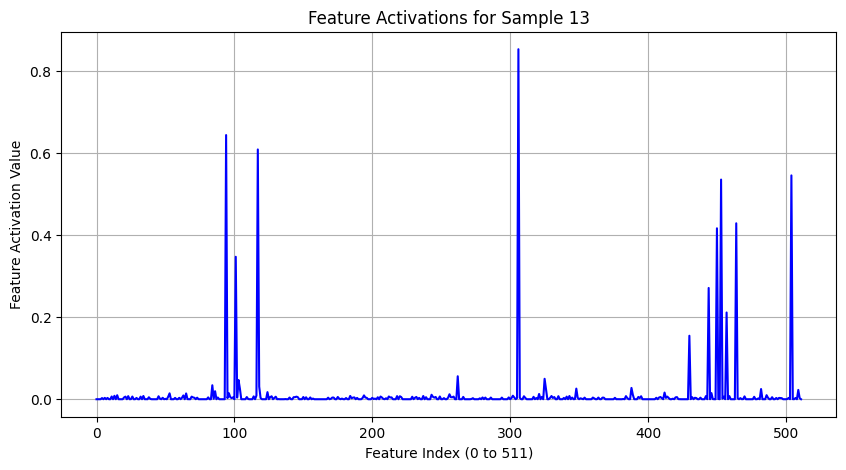

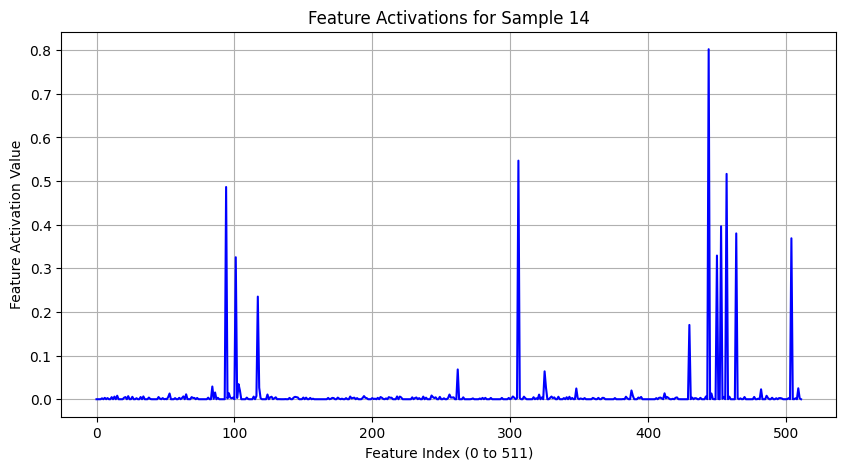

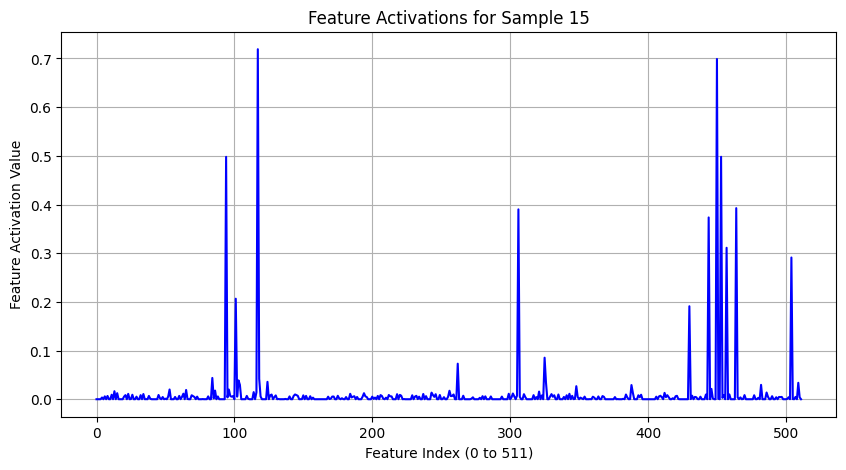

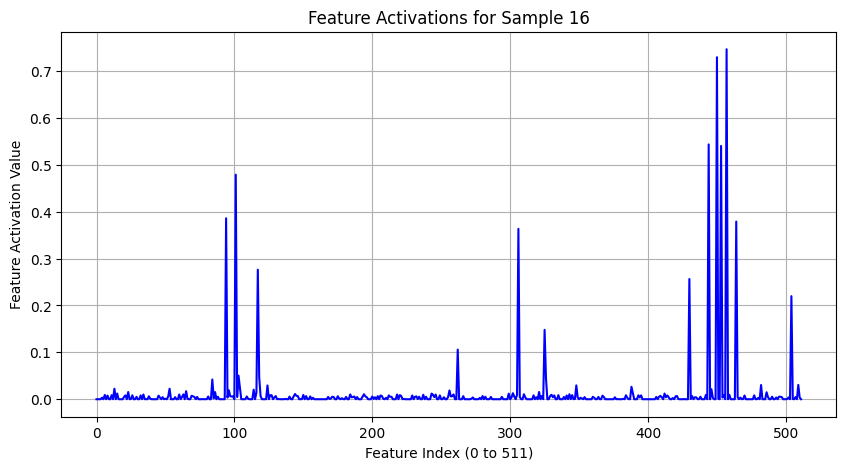

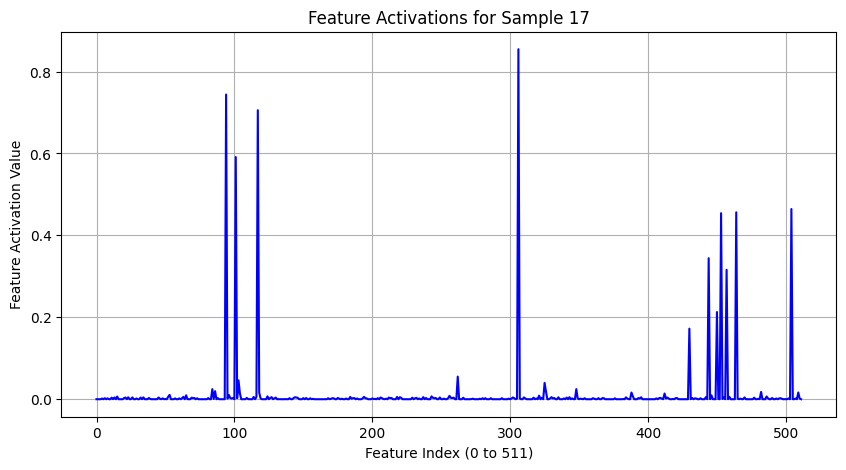

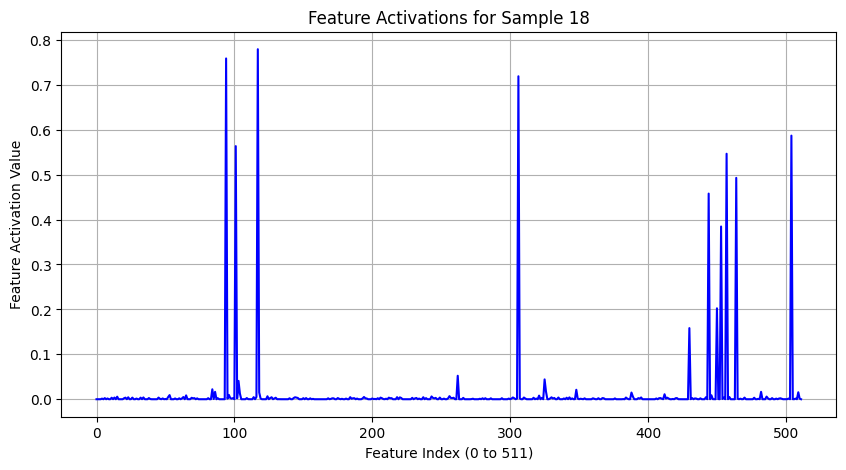

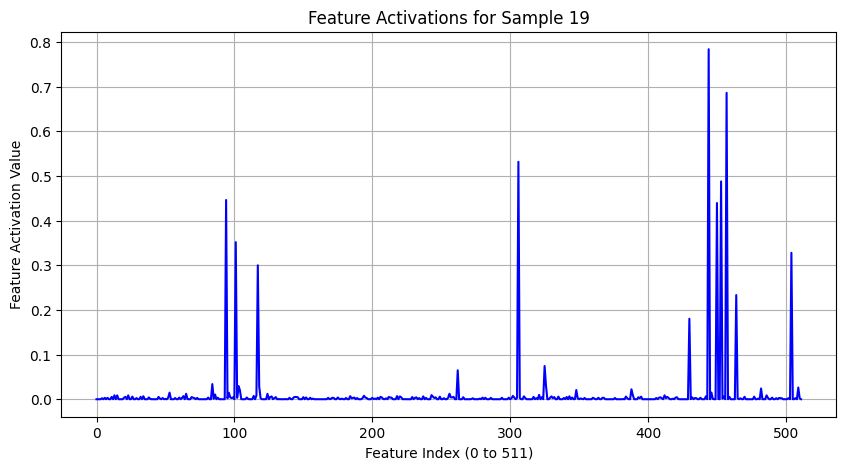

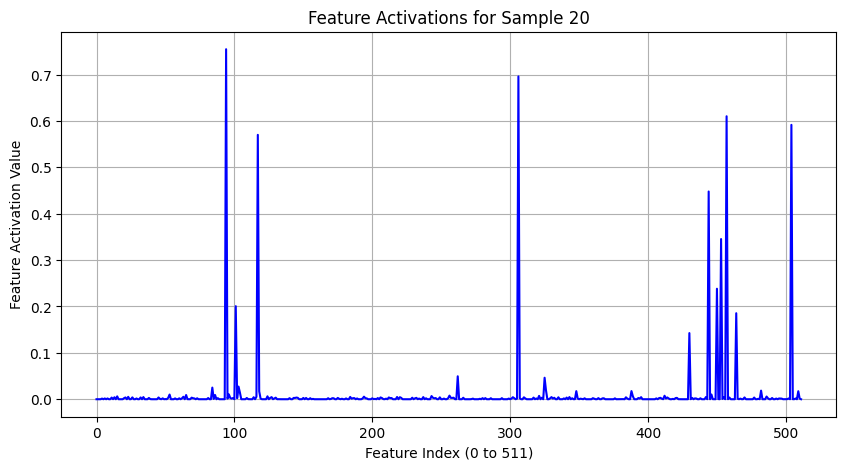

In [268]:
first_10_samples = hidden_activations[:20]

# Number of features (should be 512 based on your description)
num_features = first_10_samples.shape[1]  # 512 features for each sample

# Plot each sample in a separate plot
for i in range(20):  # Loop over the first 5 samples
    plt.figure(figsize=(10, 5))
    plt.plot(range(num_features), first_10_samples[i].cpu().numpy(), color='blue')
    plt.title(f'Feature Activations for Sample {i + 1}')
    plt.xlabel('Feature Index (0 to 511)')
    plt.ylabel('Feature Activation Value')
    plt.grid(True)
    plt.show()

In [270]:
print(f"Mean: {extracted_features.mean().item()}")
print(f"Std: {extracted_features.std().item()}")
print(f"Min: {extracted_features.min().item()}")
print(f"Max: {extracted_features.max().item()}")

Mean: -36.013580322265625
Std: 19.458263397216797
Min: -129.5471649169922
Max: 33.33001708984375


In [272]:
best_model_state = sae.state_dict()
torch.save(best_model_state, '/content/drive/MyDrive/MNIST-Inversion/SAE_Model_2.pth')


*   Saving the SAE model for using it further
*   Passing the class0 of train set through the classifer
*   then the obtained extracted_feature is passed throught the SAE
*   The feature extracted from the hidden layer for class0 is plotted
*   Plot the first three out of 6000 images where the y axis is activation value and x axis is index of the neurons
*   The same is to be done with class1 to class9
*   Then repeat it with the inversion images
*   Now see the class 0 of MNIST vs class 0 of inversion

CLASS_0_MNIST

---



In [216]:
criterion=nn.CrossEntropyLoss()
classifier_0 = Classifier(nc, ncf).to(device)
classifier_0.load_state_dict(torch.load('/content/drive/MyDrive/mnist_csf_10 (1).pth', map_location=torch.device('cpu')))

<ipython-input-216-888d1d2b9683>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  classifier_0.load_state_dict(torch.load('/content/drive/MyDrive/mnist_csf_10 (1).pth', map_

<All keys matched successfully>

extracting the hook from classifier

In [287]:
from torch.utils.data import Subset

def hook_fn(module, input, output):
    features_0.append(output)

# Find indices of class 0 in train_dataset
class0_indices = [idx for idx, (_, label) in enumerate(train_dataset) if label == 0]

# Create a subset for class 0
class0_dataset = Subset(train_dataset, class0_indices)

# Create a DataLoader for class 0
class0_loader = DataLoader(class0_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

# Verify the number of samples in the filtered dataset
print(f"Number of samples in class 0 dataset: {len(class0_dataset)}")

features_0 = []

# Register hook on the 9th layer (the first Linear layer)
hook_0_c = classifier_0.main[8].register_forward_hook(hook_fn)

# Step 5: Pass the data through the classifier and extract features
classifier_0.eval()  # Set the classifier to evaluation mode

# Iterate over the dataset to extract features
with torch.no_grad():
    for images, labels in class0_loader:
        outputs = classifier_0(images)  # Forward pass through the classifier
    hook_0_c.remove()
# Concatenate features from all batches
extracted_features_0 = torch.cat(features_0, dim=0)

print(f"Extracted features shape: {extracted_features_0.shape}")


Number of samples in class 0 dataset: 5923


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Extracted features shape: torch.Size([5923, 128])


Normalizing the extracted features, and comparing the variation in extracted and normalized features

In [288]:
print("extracted_features_0")
print(f"Mean: {extracted_features_0.mean().item()}")
print(f"Std: {extracted_features_0.std().item()}")
print(f"Min: {extracted_features_0.min().item()}")
print(f"Max: {extracted_features_0.max().item()}")
# Min-max normalization to [0, 1]
min_val_0 = extracted_features_0.min()
max_val_0 = extracted_features_0.max()
normalized_features_0 = (extracted_features_0 - min_val_0) / (max_val_0 - min_val_0 + 1e-8)  # Avoid division by zero
print("normalized_features_0")
print(f"Mean: {normalized_features_0.mean().item()}")
print(f"Std: {normalized_features_0.std().item()}")
print(f"Min: {normalized_features_0.min().item()}")
print(f"Max: {normalized_features_0.max().item()}")


extracted_features_0
Mean: -32.0715217590332
Std: 17.572662353515625
Min: -121.7175064086914
Max: 31.770435333251953
normalized_features_0
Mean: 0.5840588808059692
Std: 0.114488884806633
Min: 0.0
Max: 1.0


In [289]:
print(normalized_features_0.shape)

torch.Size([5923, 128])


In [290]:
import torch
import torch.nn as nn
import torch.optim as optim

class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, sparsity_level=0.05, beta=1e-3):
        super(SparseAutoencoder, self).__init__()
        # Hyperparameters for sparsity
        self.sparsity_level = sparsity_level
        self.beta = beta

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        hidden = self.encoder(x)
        reconstructed = self.decoder(hidden)
        return hidden, reconstructed

    def sparsity_loss(self, hidden_activations):
        # Calculate average activation of hidden layer neurons
        rho_hat = torch.mean(hidden_activations, dim=0)
        rho = self.sparsity_level

        # KL Divergence sparsity penalty
        sparsity_penalty = torch.sum(
            rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))
        )
        return sparsity_penalty

# Parameters
input_dim = 128
hidden_dim = 512
sparsity_level = 0.05  # Desired sparsity level
beta = 1e-7  # Weight of sparsity penalty
epochs = 20
batch_size = 256
learning_rate = 2*1e-2

sae_0 = SparseAutoencoder(input_dim, hidden_dim, sparsity_level, beta).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(sae.parameters(), lr=learning_rate)
sae_0.load_state_dict(torch.load('/content/drive/MyDrive/MNIST-Inversion/SAE_Model_2.pth', map_location=torch.device('cpu')))

hidden_activations_0 = []

def hook_fn(module, input, output):
    hidden_activations_0.append(output)

hook_0_s = sae_0.encoder[1].register_forward_hook(hook_fn)

# Forward pass with trained Sparse Autoencoder
print("Forward passing through the SAE to capture activations...")
with torch.no_grad():
    sae_0(normalized_features_0) #whole 6000 is passed in one batch so basically the hidden_activation consists of 128 activation tensor values for 60000 points

# Detach the hook
hook_0_s.remove()

Forward passing through the SAE to capture activations...


<ipython-input-290-5961cb6f70ae>:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sae_0.load_state_dict(torch.load('/content/drive/MyDrive/MNIST-Inversion/SAE_Model_2.pth',

In [291]:
hidden_activations_0=torch.cat(hidden_activations_0, dim=0)
print(f"Mean: {hidden_activations_0.mean().item()}")
print(f"Std: {hidden_activations_0.std().item()}")
print(f"Min: {hidden_activations_0.min().item()}")
print(f"Max: {hidden_activations_0.max().item()}")

Mean: 0.011868702247738838
Std: 0.06868211925029755
Min: 4.099030915194203e-24
Max: 0.9484614729881287


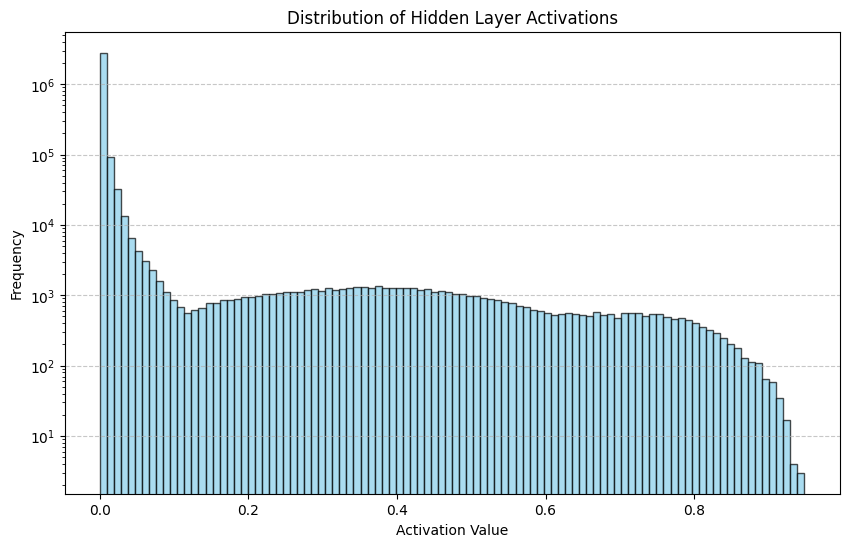

In [293]:
import matplotlib.pyplot as plt

# Assuming hidden_activations is already obtained as a tensor
hidden_activations_0_np = hidden_activations_0.detach().cpu().numpy()  # Convert to numpy array

# Flatten the tensor to analyze all activations across images and neurons
flattened_activations = hidden_activations_0_np.flatten()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(flattened_activations, bins=100, color='skyblue', alpha=0.7, edgecolor='black')
plt.title("Distribution of Hidden Layer Activations")
plt.yscale('log')
plt.xlabel("Activation Value")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

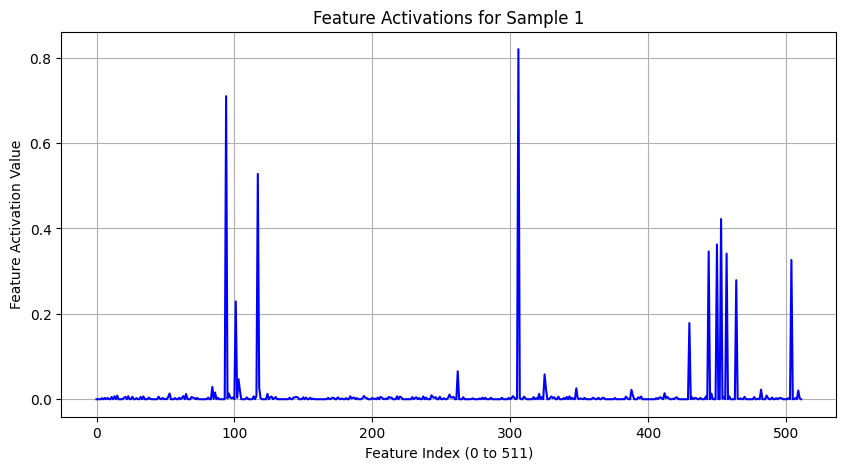

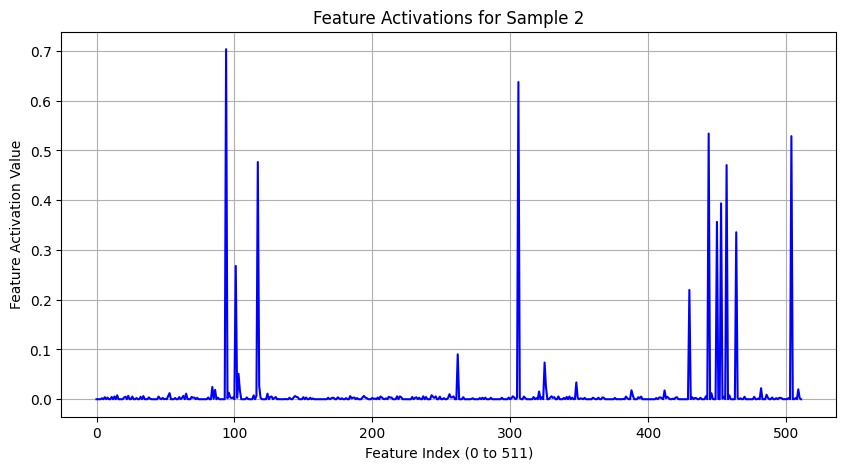

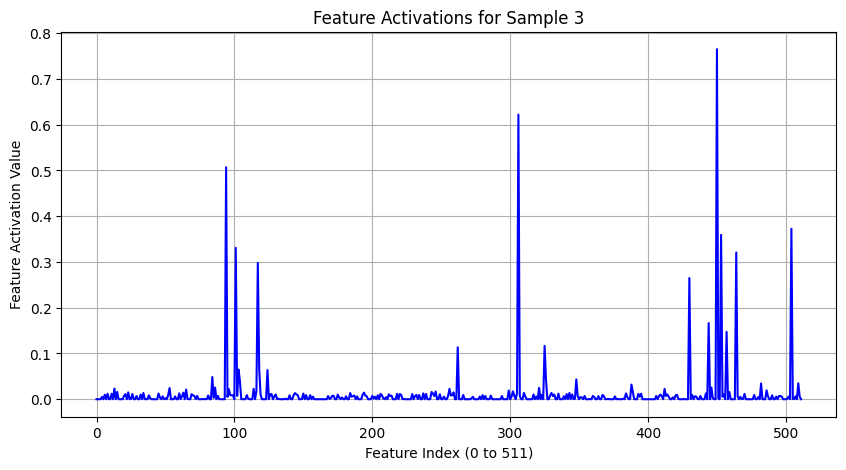

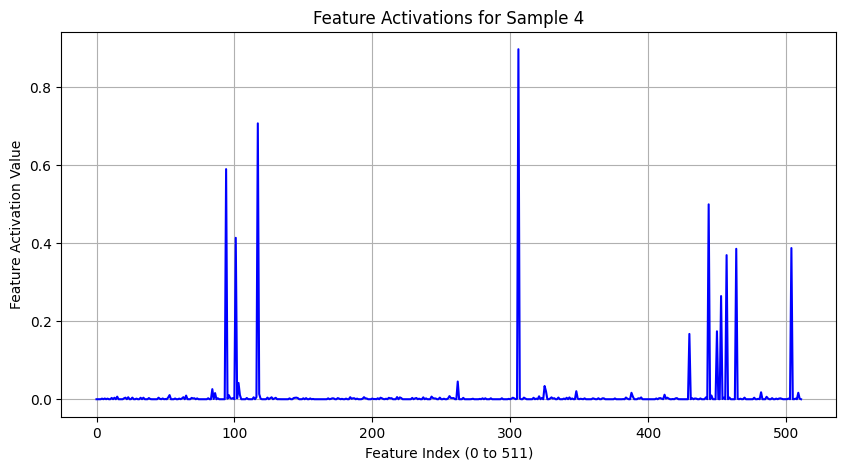

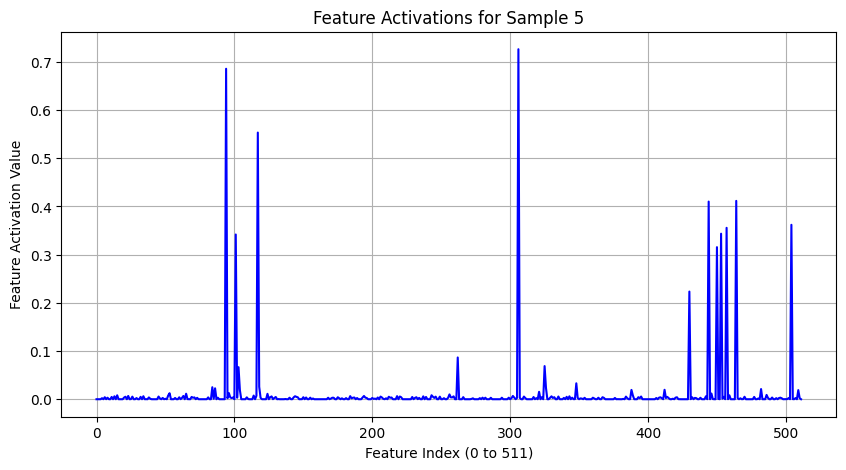

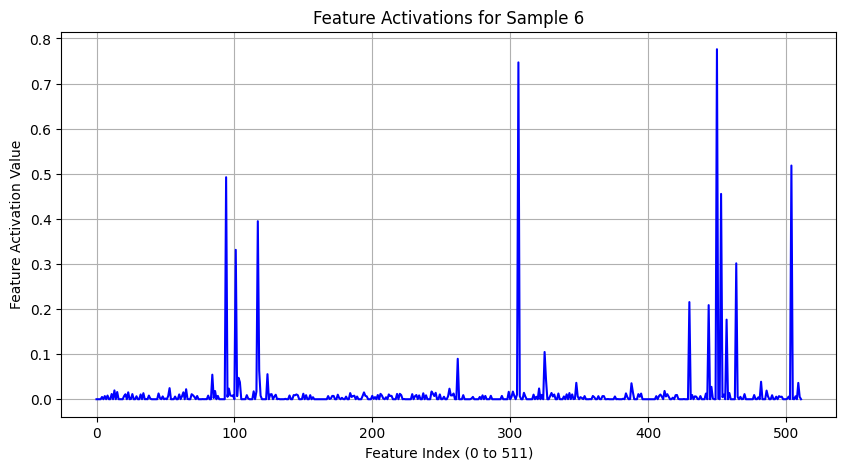

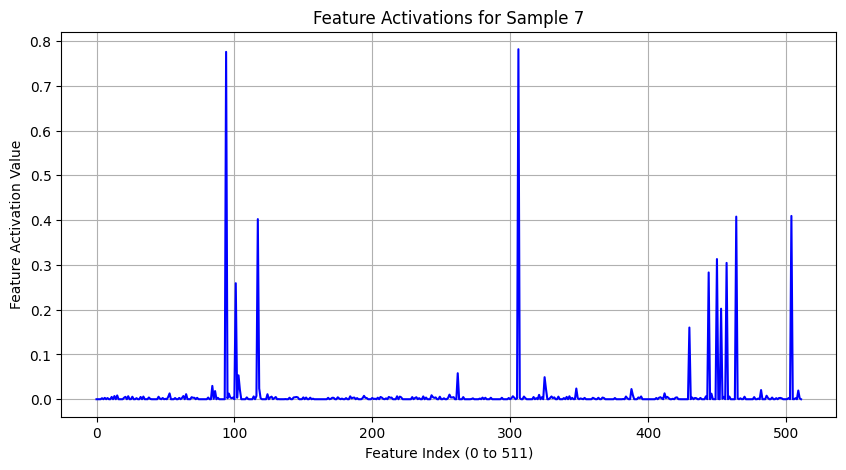

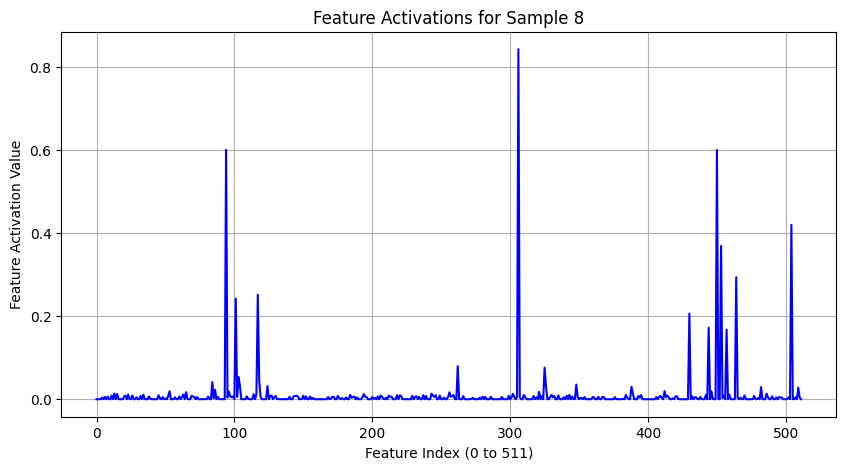

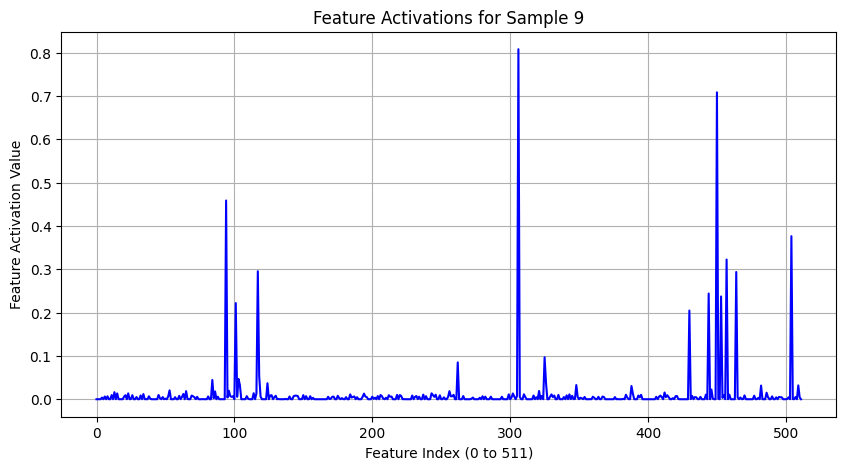

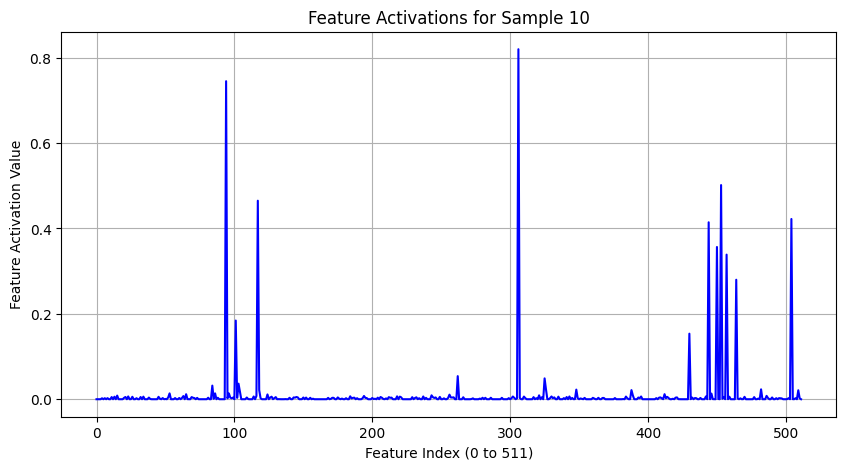

In [295]:
first_10_samples = hidden_activations_0[:10]

# Number of features (should be 512 based on your description)
num_features = first_10_samples.shape[1]  # 512 features for each sample

# Plot each sample in a separate plot
for i in range(10):  # Loop over the first 5 samples
    plt.figure(figsize=(10, 5))
    plt.plot(range(num_features), first_10_samples[i].cpu().numpy(), color='blue')
    plt.title(f'Feature Activations for Sample {i + 1}')
    plt.xlabel('Feature Index (0 to 511)')
    plt.ylabel('Feature Activation Value')
    plt.grid(True)
    plt.show()

CLASS_4_MNIST

---



In [299]:
criterion=nn.CrossEntropyLoss()
classifier_4 = Classifier(nc, ncf).to(device)
classifier_4.load_state_dict(torch.load('/content/drive/MyDrive/mnist_csf_10 (1).pth', map_location=torch.device('cpu')))

<ipython-input-299-d86bab73c3fa>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  classifier_4.load_state_dict(torch.load('/content/drive/MyDrive/mnist_csf_10 (1).pth', map_

<All keys matched successfully>

In [315]:
from torch.utils.data import Subset

def hook_fn(module, input, output):
    features_4.append(output)

# Find indices of class 0 in train_dataset
class4_indices = [idx for idx, (_, label) in enumerate(train_dataset) if label == 7]

# Create a subset for class 0
class4_dataset = Subset(train_dataset, class4_indices)

# Create a DataLoader for class 0
class4_loader = DataLoader(class4_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

# Verify the number of samples in the filtered dataset
print(f"Number of samples in class 0 dataset: {len(class4_dataset)}")

features_4 = []

# Register hook on the 9th layer (the first Linear layer)
hook_4_c = classifier_4.main[8].register_forward_hook(hook_fn)

# Step 5: Pass the data through the classifier and extract features
classifier_4.eval()  # Set the classifier to evaluation mode

# Iterate over the dataset to extract features
with torch.no_grad():
    for images, labels in class4_loader:
        outputs = classifier_4(images)  # Forward pass through the classifier
    hook_4_c.remove()
# Concatenate features from all batches
extracted_features_4 = torch.cat(features_4, dim=0)

print(f"Extracted features shape: {extracted_features_4.shape}")


Number of samples in class 0 dataset: 6265
Extracted features shape: torch.Size([6265, 128])


In [316]:
print("extracted_features_0")
print(f"Mean: {extracted_features_4.mean().item()}")
print(f"Std: {extracted_features_4.std().item()}")
print(f"Min: {extracted_features_4.min().item()}")
print(f"Max: {extracted_features_4.max().item()}")
# Min-max normalization to [0, 1]
min_val_4 = extracted_features_4.min()
max_val_4 = extracted_features_4.max()
normalized_features_4 = (extracted_features_4 - min_val_4) / (max_val_4 - min_val_4 + 1e-8)  # Avoid division by zero
print("normalized_features_4")
print(f"Mean: {normalized_features_4.mean().item()}")
print(f"Std: {normalized_features_4.std().item()}")
print(f"Min: {normalized_features_4.min().item()}")
print(f"Max: {normalized_features_4.max().item()}")


extracted_features_0
Mean: -35.78989791870117
Std: 19.258089065551758
Min: -122.44937896728516
Max: 29.781625747680664
normalized_features_4
Mean: 0.5692629814147949
Std: 0.12650568783283234
Min: 0.0
Max: 1.0


In [317]:
print(normalized_features_4.shape)

torch.Size([6265, 128])


In [318]:
import torch
import torch.nn as nn
import torch.optim as optim

class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, sparsity_level=0.05, beta=1e-3):
        super(SparseAutoencoder, self).__init__()
        # Hyperparameters for sparsity
        self.sparsity_level = sparsity_level
        self.beta = beta

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        hidden = self.encoder(x)
        reconstructed = self.decoder(hidden)
        return hidden, reconstructed

    def sparsity_loss(self, hidden_activations):
        # Calculate average activation of hidden layer neurons
        rho_hat = torch.mean(hidden_activations, dim=0)
        rho = self.sparsity_level

        # KL Divergence sparsity penalty
        sparsity_penalty = torch.sum(
            rho * torch.log(rho / rho_hat) + (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))
        )
        return sparsity_penalty

# Parameters
input_dim = 128
hidden_dim = 512
sparsity_level = 0.05  # Desired sparsity level
beta = 1e-7  # Weight of sparsity penalty
epochs = 20
batch_size = 256
learning_rate = 2*1e-2

sae_4 = SparseAutoencoder(input_dim, hidden_dim, sparsity_level, beta).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(sae.parameters(), lr=learning_rate)
sae_4.load_state_dict(torch.load('/content/drive/MyDrive/MNIST-Inversion/SAE_Model_2.pth', map_location=torch.device('cpu')))

hidden_activations_4 = []

def hook_fn(module, input, output):
    hidden_activations_4.append(output)

hook_4_s = sae_4.encoder[1].register_forward_hook(hook_fn)

# Forward pass with trained Sparse Autoencoder
print("Forward passing through the SAE to capture activations...")
with torch.no_grad():
    sae_4(normalized_features_4) #whole 6000 is passed in one batch so basically the hidden_activation consists of 128 activation tensor values for 60000 points

# Detach the hook
hook_4_s.remove()

Forward passing through the SAE to capture activations...


<ipython-input-318-b284d0a4c401>:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sae_4.load_state_dict(torch.load('/content/drive/MyDrive/MNIST-Inversion/SAE_Model_2.pth',

In [319]:
hidden_activations_4=torch.cat(hidden_activations_4, dim=0)
print(f"Mean: {hidden_activations_4.mean().item()}")
print(f"Std: {hidden_activations_4.std().item()}")
print(f"Min: {hidden_activations_4.min().item()}")
print(f"Max: {hidden_activations_4.max().item()}")

Mean: 0.0119770597666502
Std: 0.06646829098463058
Min: 5.375758902944624e-23
Max: 0.9075987935066223


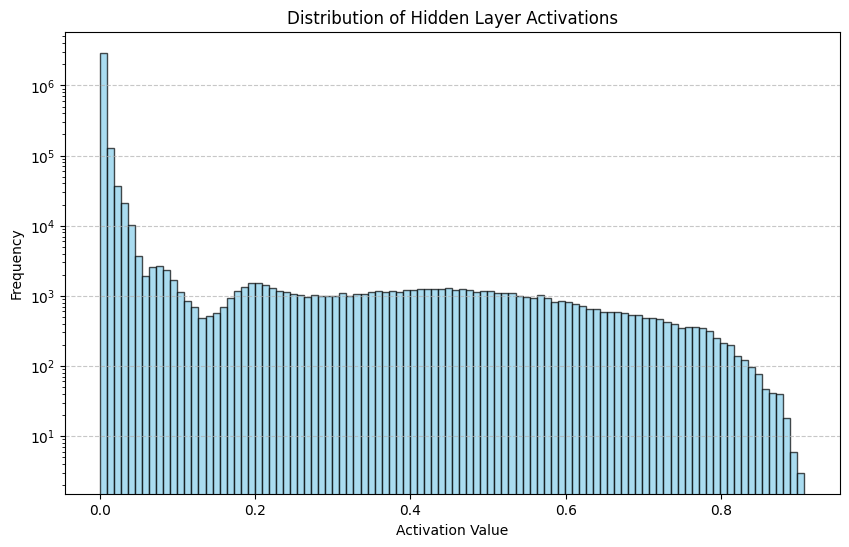

In [320]:
import matplotlib.pyplot as plt

# Assuming hidden_activations is already obtained as a tensor
hidden_activations_4_np = hidden_activations_4.detach().cpu().numpy()  # Convert to numpy array

# Flatten the tensor to analyze all activations across images and neurons
flattened_activations = hidden_activations_4_np.flatten()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(flattened_activations, bins=100, color='skyblue', alpha=0.7, edgecolor='black')
plt.title("Distribution of Hidden Layer Activations")
plt.yscale('log')
plt.xlabel("Activation Value")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

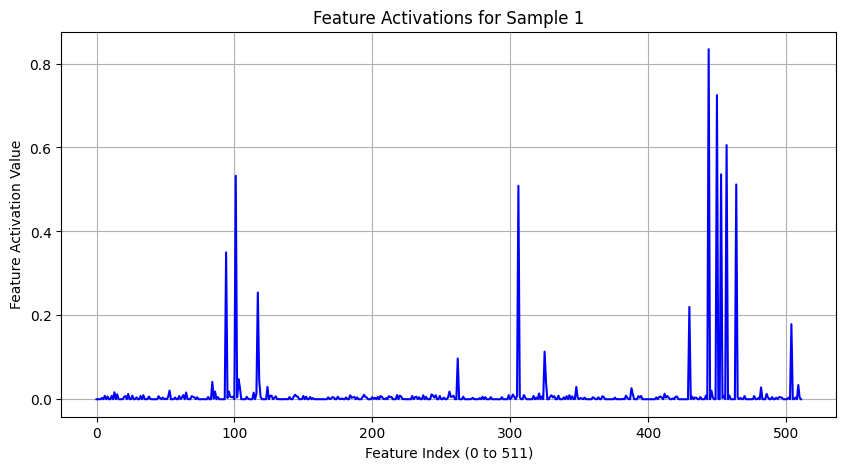

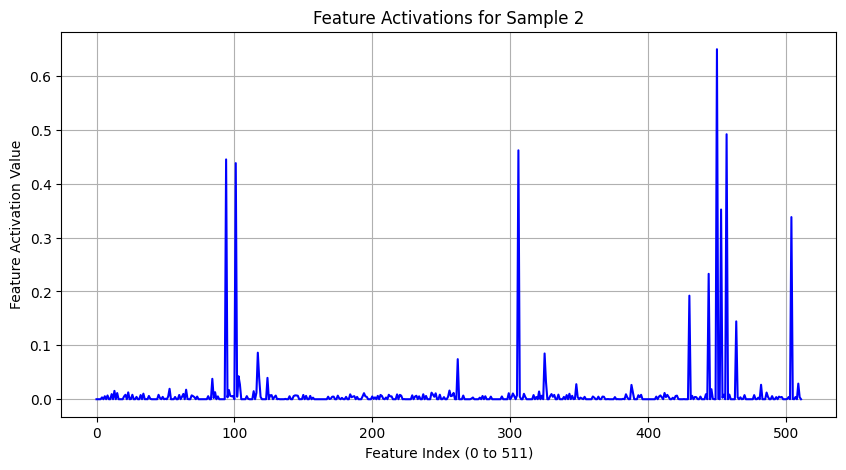

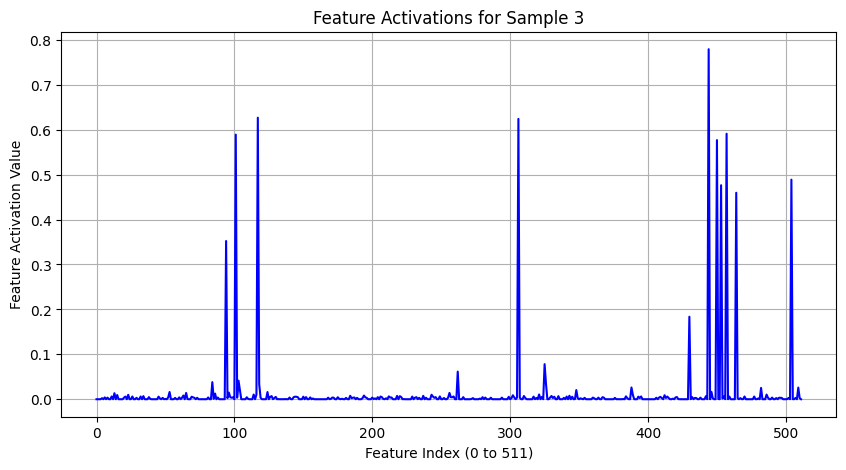

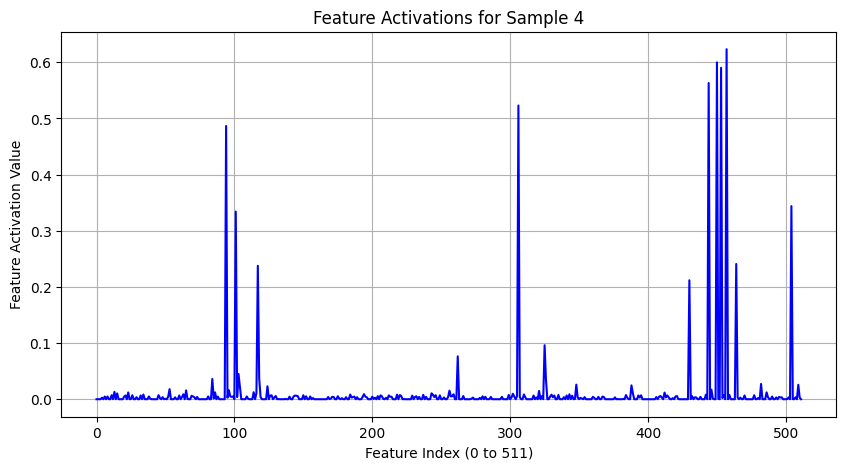

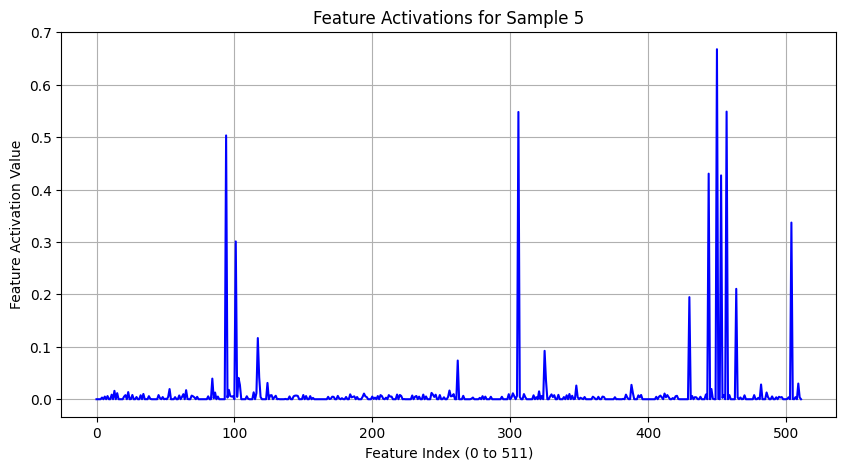

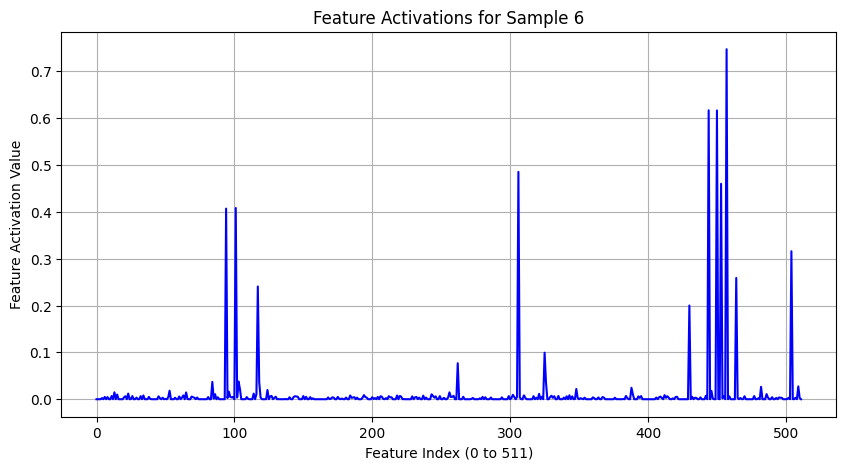

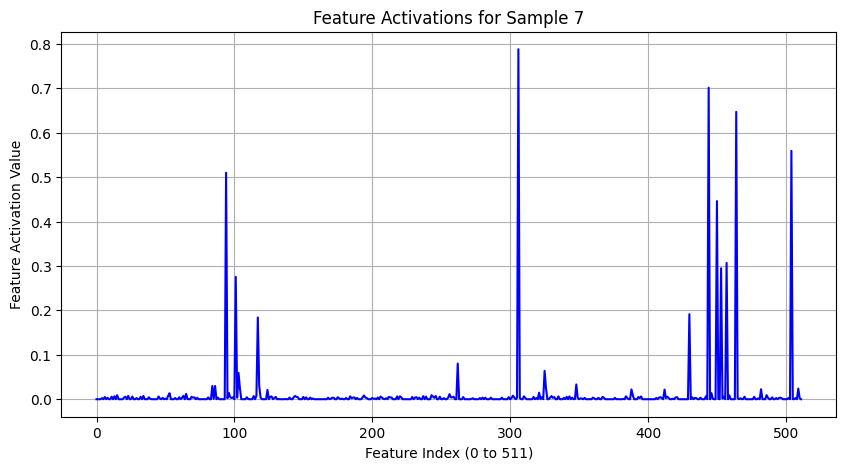

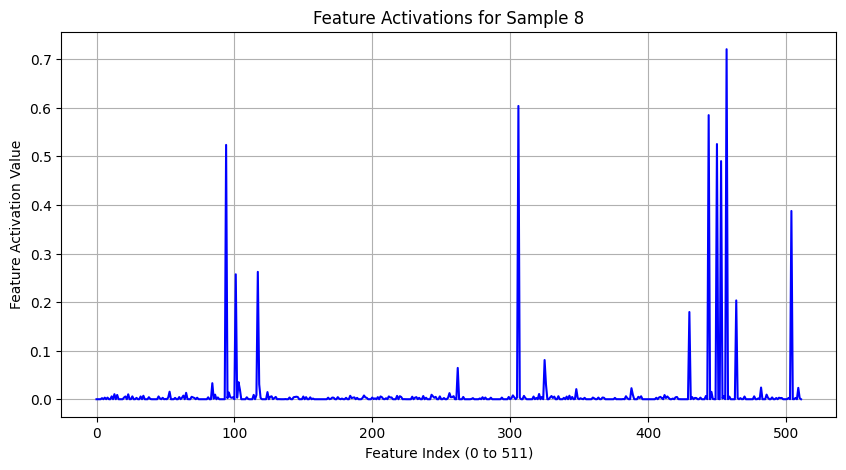

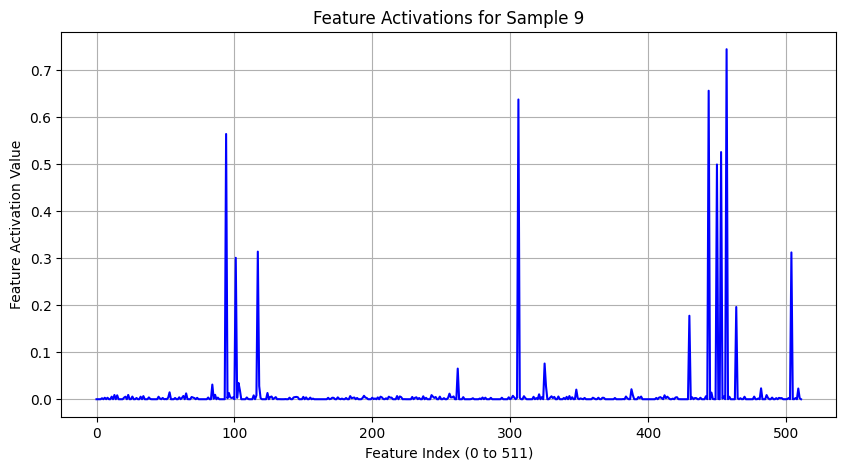

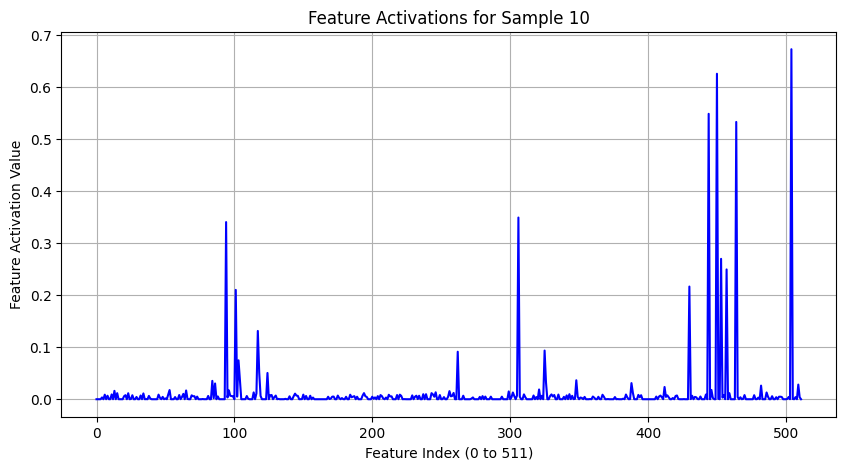

In [321]:
first_10_samples = hidden_activations_4[:10]

# Number of features (should be 512 based on your description)
num_features = first_10_samples.shape[1]  # 512 features for each sample

# Plot each sample in a separate plot
for i in range(10):  # Loop over the first 5 samples
    plt.figure(figsize=(10, 5))
    plt.plot(range(num_features), first_10_samples[i].cpu().numpy(), color='blue')
    plt.title(f'Feature Activations for Sample {i + 1}')
    plt.xlabel('Feature Index (0 to 511)')
    plt.ylabel('Feature Activation Value')
    plt.grid(True)
    plt.show()

GENERATING IMAGE FOR EACH CLASS

In [220]:
import os
import torch
import shutil
from torchvision import transforms
from PIL import Image

nc=1
ncf=64
# Load the pre-trained classifier
criterion=nn.CrossEntropyLoss()
classifier = Classifier(nc, ncf).to(device)
classifier.load_state_dict(torch.load('/content/drive/MyDrive/mnist_csf_10 (1).pth', map_location=torch.device('cpu')))
classifier.eval()

# Input and output folder paths
input_folder = "path_to_images_folder"  # Folder containing the 2000 images
output_folder = "path_to_classified_images"  # Folder to save classified images by class

# Ensure output folder exists and has subfolders for 10 classes
for class_idx in range(10):
    class_folder = os.path.join(output_folder, str(class_idx))
    os.makedirs(class_folder, exist_ok=True)

# Image transformations (if needed for the classifier)
transform = transforms.Compose([
    transforms.Resize((28, 28)),  # Resize images (adjust as per model input requirements)
    transforms.ToTensor(),       # Convert image to tensor
    transforms.Normalize((0.5,), (0.5,)),  # Normalize (adjust as per training normalization)
])

# Classify and save images
with torch.no_grad():
    for image_name in os.listdir(input_folder):
        input_image_path = os.path.join(input_folder, image_name)

        # Open and preprocess the image
        try:
            image = Image.open(input_image_path).convert("L")  # Convert to grayscale if needed
            image_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension

            # Predict class
            output = classifier(image_tensor)
            predicted_class = torch.argmax(output, dim=1).item()

            # Move image to the predicted class folder
            output_image_path = os.path.join(output_folder, str(predicted_class), image_name)
            shutil.copy(input_image_path, output_image_path)
        except Exception as e:
            print(f"Error processing {image_name}: {e}")


tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

INVERSION FOR GENERATING IMAGES

---

